In [5]:
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize
from skimage.draw import line
import json
from scipy.spatial import KDTree
import os

import geo_utils as gu

In [6]:
chkp0_chunk_coords = (39, 0)
chkp1_chunk_coords = (0, 11)
chkp2_chunk_coords = (42, 10)
chkp3_chunk_coords = (3,22)

p0 = gu.chunk_coord_to_pixel_coord(chkp0_chunk_coords[0], chkp0_chunk_coords[1]) + gu.CHUNK_DIM/2
p1 = gu.chunk_coord_to_pixel_coord(chkp1_chunk_coords[0], chkp1_chunk_coords[1]) + gu.CHUNK_DIM/2
p3 = gu.chunk_coord_to_pixel_coord(chkp3_chunk_coords[0], chkp3_chunk_coords[1]) + gu.CHUNK_DIM/2

v_primary = p1 - p0
v_step = p3 - p1

length_primary = np.linalg.norm(v_primary)
length_step = np.linalg.norm(v_step)

unit_primary = v_primary / length_primary
unit_step = v_step / length_step

step_size = gu.CHUNK_DIM
num_steps = int(length_step // step_size)

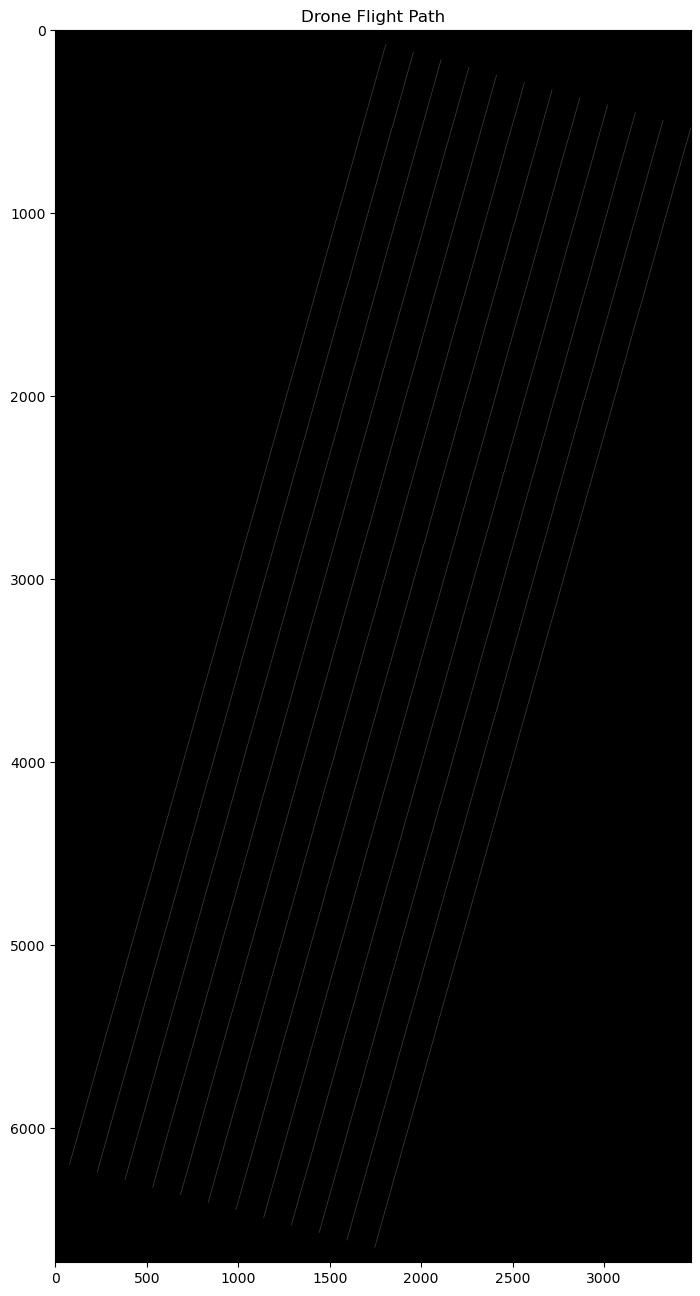

In [7]:
flight_path = np.zeros_like(gu.ndvi)

for i in range(num_steps + 1):
    offset = unit_step * (i * step_size)
    start = p0 + offset
    end = p1 + offset

    sweep_length = np.linalg.norm(end - start)
    num_chunks_along = int(sweep_length // gu.CHUNK_DIM)
    
    if i % 2 == 0:
        direction = 1
    else:
        direction = -1

    prev_point = None
    for j in range(num_chunks_along + 1):
        t = j / num_chunks_along if direction == 1 else 1 - (j / num_chunks_along)
        point = start * (1 - t) + end * t
        y, x = int(round(point[0])), int(round(point[1]))

        if prev_point is not None:
            rr, cc = line(prev_point[0], prev_point[1], y, x)
            rr = np.clip(rr, 0, flight_path.shape[0] - 1)
            cc = np.clip(cc, 0, flight_path.shape[1] - 1)
            flight_path[rr, cc] = 1
        else:
            if 0 <= y < flight_path.shape[0] and 0 <= x < flight_path.shape[1]:
                flight_path[y, x] = 1

        prev_point = (y, x)

plt.figure(figsize=(10,16))
plt.imshow(flight_path, cmap="gray")
plt.title("Drone Flight Path")
plt.show()

In [8]:
os.makedirs(os.path.dirname("Data/DronePaths_npy/lawnmower.npy"), exist_ok=True)
np.save("Data/DronePaths_npy/lawnmower.npy", flight_path)